# Agentic Biomarker Discovery — Notebook 1
## Data Parsing, Biomedical Embeddings & FAISS Index

**Contents:** BioASQ corpus → PubMedBERT embeddings → FAISS index → Recall@k evaluation

**Embedding model:** `microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext`  
Domain-specific biomedical model trained on 21B words of PubMed text (dim=768).

---

This notebook establishes the retrieval foundation for the project: it parses the
BioASQ Task 8B training corpus, embeds all snippets with a biomedical sentence
encoder, builds a FAISS IndexFlatIP for exact cosine search, and evaluates retrieval
quality with Recall@k on a held-out test set.


---
## Cell 0 — Cache Control

Set `FORCE_REBUILD = True` to clear all cached index files and rebuild from scratch.
**Must be `True` when changing the embedding model.**

In [1]:
# ── Cache Control ─────────────────────────────────────────────────
# FORCE_REBUILD = True  → clears all cached files and rebuilds
# FORCE_REBUILD = False → loads cached files (faster re-runs)
# Must be True when switching embedding models (MiniLM → PubMedBERT)
FORCE_REBUILD = True   # ← set False after first successful run

import os

BASE_DIR  = '/content/drive/MyDrive/this project/Final'
INDEX_DIR = os.path.join(BASE_DIR, 'index')

if FORCE_REBUILD:
    files_to_clear = [
        os.path.join(INDEX_DIR, 'corpus_snippets.pkl'),
        os.path.join(INDEX_DIR, 'corpus_embeddings.npy'),
        os.path.join(INDEX_DIR, 'bioasq_faiss.index'),
        os.path.join(INDEX_DIR, 'question_splits.pkl'),
    ]
    cleared = 0
    for fp in files_to_clear:
        if os.path.exists(fp):
            os.remove(fp)
            print(f'  Cleared: {os.path.basename(fp)}')
            cleared += 1
    print(f'Cache cleared ({cleared} files removed) — will rebuild from scratch')
else:
    print('FORCE_REBUILD = False — using cached files where available')


  Cleared: corpus_snippets.pkl
  Cleared: corpus_embeddings.npy
  Cleared: bioasq_faiss.index
  Cleared: question_splits.pkl
Cache cleared (4 files removed) — will rebuild from scratch


---
## Cell 1 — Install Dependencies

In [2]:
!pip install -q \
    sentence-transformers \
    faiss-cpu \
    tqdm

print('✓ Dependencies installed')

✓ Dependencies installed


---
## Cell 2 — Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

os.makedirs(INDEX_DIR, exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, 'results'), exist_ok=True)

print(f'Base dir  : {BASE_DIR}')
print(f'Index dir : {INDEX_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Base dir  : /content/drive/MyDrive/csci_e222/Final
Index dir : /content/drive/MyDrive/csci_e222/Final/index


---
## Cell 3 — Verify Required Files

In [4]:
required_files = {
    'BioASQ-training8b.zip' : 'Training data (3,243 questions)',
    '8B1_golden.json'       : 'Test batch 1 (100 questions)',
    '8B2_golden.json'       : 'Test batch 2 (100 questions)',
    '8B3_golden.json'       : 'Test batch 3 (100 questions)',
    '8B4_golden.json'       : 'Test batch 4 (100 questions)',
    '8B5_golden.json'       : 'Test batch 5 (100 questions)',
}
all_ok = True
print('File check:')
for fname, desc in required_files.items():
    fp     = os.path.join(BASE_DIR, fname)
    exists = os.path.exists(fp)
    size   = os.path.getsize(fp)/1024/1024 if exists else 0
    status = f'OK  {size:.1f} MB' if exists else 'MISSING'
    print(f'  {status}  |  {fname:<30} ({desc})')
    if not exists: all_ok = False
if not all_ok:
    raise FileNotFoundError(f'Missing files in {BASE_DIR}. Upload and re-run.')
print('\nAll files present')

File check:
  OK  4.0 MB  |  BioASQ-training8b.zip          (Training data (3,243 questions))
  OK  0.5 MB  |  8B1_golden.json                (Test batch 1 (100 questions))
  OK  0.5 MB  |  8B2_golden.json                (Test batch 2 (100 questions))
  OK  0.6 MB  |  8B3_golden.json                (Test batch 3 (100 questions))
  OK  0.5 MB  |  8B4_golden.json                (Test batch 4 (100 questions))
  OK  0.4 MB  |  8B5_golden.json                (Test batch 5 (100 questions))

All files present


---
## Cell 4 — Import Libraries

In [5]:
import json, pickle, zipfile, warnings
from collections import Counter
from typing import List, Dict

import numpy as np
import matplotlib.pyplot as plt
import faiss
import torch
from tqdm import tqdm
from sentence_transformers import SentenceTransformer

warnings.filterwarnings('ignore')
SEED   = 42
np.random.seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Libraries imported')
print(f'  Device  : {device}')
if device == 'cuda':
    print(f'  GPU     : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'  FAISS   : {faiss.__version__}')

Libraries imported
  Device  : cuda
  GPU     : NVIDIA RTX PRO 6000 Blackwell Server Edition
  VRAM    : 102.0 GB
  FAISS   : 1.13.2


---
## Cell 5 — Load BioASQ Data

In [6]:
TRAIN_JSON = os.path.join(BASE_DIR, 'training8b.json')
TRAIN_ZIP  = os.path.join(BASE_DIR, 'BioASQ-training8b.zip')

if not os.path.exists(TRAIN_JSON):
    print('Extracting BioASQ-training8b.zip...')
    with zipfile.ZipFile(TRAIN_ZIP, 'r') as z:
        z.extract('training8b.json', BASE_DIR)
    print('  Extracted')
else:
    print('  training8b.json already extracted')

with open(TRAIN_JSON, 'r', encoding='utf-8') as f:
    train_questions = json.load(f)['questions']
print(f'Training questions : {len(train_questions):,}')

golden_questions = []
for i in range(1, 6):
    fp = os.path.join(BASE_DIR, f'8B{i}_golden.json')
    with open(fp, 'r', encoding='utf-8') as f:
        batch = json.load(f)['questions']
    golden_questions.extend(batch)
    print(f'  8B{i}_golden.json : {len(batch)} questions')

print(f'Test questions     : {len(golden_questions):,}')
print(f'Grand total        : {len(train_questions)+len(golden_questions):,}')

  training8b.json already extracted
Training questions : 3,243
  8B1_golden.json : 100 questions
  8B2_golden.json : 100 questions
  8B3_golden.json : 100 questions
  8B4_golden.json : 100 questions
  8B5_golden.json : 100 questions
Test questions     : 500
Grand total        : 3,743


---
## Cell 6 — Dataset Statistics

Only **factoid** and **list** question types are used for agent evaluation.

In [7]:
def type_distribution(questions: List[Dict], label: str) -> Counter:
    counts = Counter(q['type'] for q in questions)
    total  = len(questions)
    print(f'\n{label} ({total:,} total)')
    print(f"  {'Type':<12} {'Count':>6}  {'%':>6}")
    print(f"  {'-'*28}")
    for qtype in ['factoid', 'list', 'yesno', 'summary']:
        n = counts.get(qtype, 0)
        print(f'  {qtype:<12} {n:>6,}  {n/total*100:>5.1f}%')
    return counts

train_counts  = type_distribution(train_questions,  'Training Set')
golden_counts = type_distribution(golden_questions, 'Test Set (Golden)')

EVAL_TYPES    = {'factoid', 'list'}
train_eval_qs = [q for q in train_questions  if q['type'] in EVAL_TYPES]
test_eval_qs  = [q for q in golden_questions if q['type'] in EVAL_TYPES]

print(f'\nFactoid + List (agent evaluation):')
print(f'  Training : {len(train_eval_qs):,}')
print(f'  Test     : {len(test_eval_qs):,}')


Training Set (3,243 total)
  Type          Count       %
  ----------------------------
  factoid         941   29.0%
  list            644   19.9%
  yesno           881   27.2%
  summary         777   24.0%

Test Set (Golden) (500 total)
  Type          Count       %
  ----------------------------
  factoid         151   30.2%
  list             75   15.0%
  yesno           152   30.4%
  summary         122   24.4%

Factoid + List (agent evaluation):
  Training : 1,585
  Test     : 226


---
## Cell 7 — Visualise Question Type Distribution

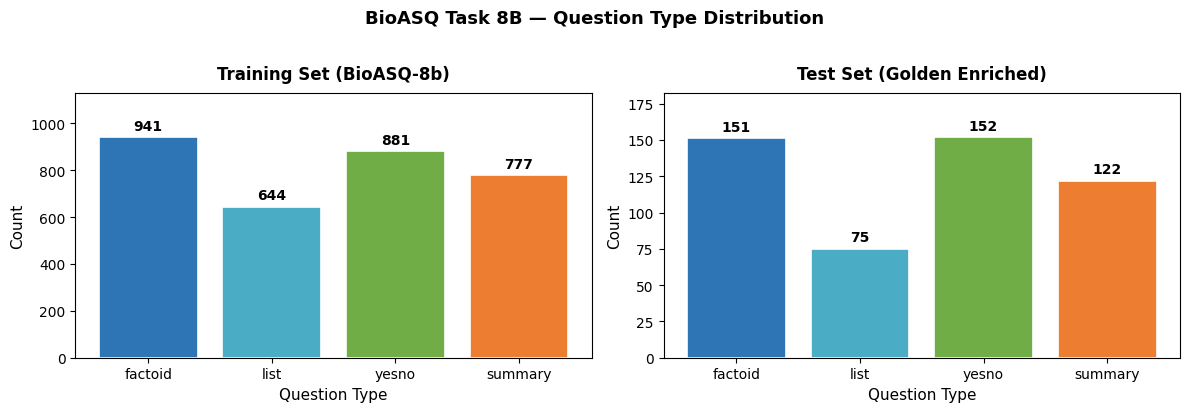

Chart saved -> /content/drive/MyDrive/csci_e222/Final/question_distribution.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
QTYPES = ['factoid', 'list', 'yesno', 'summary']
COLORS = ['#2E75B6', '#4BACC6', '#70AD47', '#ED7D31']

for ax, (counts, label) in zip(axes, [
    (train_counts,  'Training Set (BioASQ-8b)'),
    (golden_counts, 'Test Set (Golden Enriched)'),
]):
    vals = [counts.get(t, 0) for t in QTYPES]
    bars = ax.bar(QTYPES, vals, color=COLORS, edgecolor='white', linewidth=1.2)
    ax.set_title(label, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Question Type', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_ylim(0, max(vals)*1.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.02,
                str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('BioASQ Task 8B — Question Type Distribution',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
out = os.path.join(BASE_DIR, 'question_distribution.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved -> {out}')

---
## Cell 8 — Extract & Deduplicate Snippet Corpus

Each BioASQ question includes supporting PubMed snippets. We extract all snippets from training data, deduplicate by text, and build a flat corpus for indexing.

In [9]:
def extract_snippets(questions: List[Dict]) -> List[Dict]:
    """Extract unique PubMed snippets from BioASQ questions."""
    seen_texts = set()
    snippets   = []
    for q in tqdm(questions, desc='Extracting snippets'):
        for s in q.get('snippets', []):
            text = s['text'].strip()
            if not text or text in seen_texts:
                continue
            seen_texts.add(text)
            snippets.append({
                'snippet_id'   : len(snippets),
                'text'         : text,
                'pubmed_url'   : s.get('document', ''),
                'begin_section': s.get('beginSection', ''),
                'question_id'  : q['id'],
                'question_type': q['type'],
            })
    return snippets

raw_count       = sum(len(q.get('snippets', [])) for q in train_questions)
corpus_snippets = extract_snippets(train_questions)
lengths         = [len(s['text'].split()) for s in corpus_snippets]

print(f'\nSnippet corpus built')
print(f'  Raw snippets (with duplicates) : {raw_count:,}')
print(f'  Unique snippets (corpus)       : {len(corpus_snippets):,}')
print(f'  Avg snippet length (words)     : {np.mean(lengths):.1f}')
print(f'  Median snippet length (words)  : {np.median(lengths):.0f}')

Extracting snippets: 100%|██████████| 3243/3243 [00:00<00:00, 122486.52it/s]


Snippet corpus built
  Raw snippets (with duplicates) : 41,915
  Unique snippets (corpus)       : 38,939
  Avg snippet length (words)     : 29.1
  Median snippet length (words)  : 24


---
## Cell 9 — Save Corpus to Drive

In [10]:
CORPUS_PATH = os.path.join(INDEX_DIR, 'corpus_snippets.pkl')
with open(CORPUS_PATH, 'wb') as f:
    pickle.dump(corpus_snippets, f)
print(f'Corpus saved -> {CORPUS_PATH}')
print(f'  File size: {os.path.getsize(CORPUS_PATH)/1024/1024:.1f} MB')

Corpus saved -> /content/drive/MyDrive/csci_e222/Final/index/corpus_snippets.pkl
  File size: 11.1 MB


---
## Cell 10 — Load PubMedBERT Embedding Model

**PubMedBERT** (`BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext`) is trained on 21B words
of PubMed abstracts and full-text articles. It produces 768-dim vectors and provides superior
separation of biomedical entities (gene names, clinical terms, drug names) compared to
general-purpose models like all-MiniLM-L6-v2 (384-dim).

The previous model is shown below commented out for reference.

In [11]:
# Previous general-purpose model (dim=384) — commented out:
# EMBED_MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'

# PubMedBERT — biomedical domain (dim=768)
#EMBED_MODEL_NAME = 'microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext'
EMBED_MODEL_NAME = 'pritamdeka/S-PubMedBert-MS-MARCO'

embed_model = SentenceTransformer(EMBED_MODEL_NAME, device=device)
EMBED_DIM   = embed_model.get_sentence_embedding_dimension()

print(f'Embedding model loaded')
print(f'  Model  : {EMBED_MODEL_NAME}')
print(f'  Device : {device}')
print(f'  Dim    : {EMBED_DIM} (PubMedBERT) vs 384 (MiniLM baseline)')
print(f'  Domain : Biomedical (PubMed abstracts + full-text)')

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded
  Model  : pritamdeka/S-PubMedBert-MS-MARCO
  Device : cuda
  Dim    : 768 (PubMedBERT) vs 384 (MiniLM baseline)
  Domain : Biomedical (PubMed abstracts + full-text)


---
## Cell 11 — Embed the Corpus

Encode all ~39K snippets. PubMedBERT (dim=768) is slightly slower than MiniLM but produces domain-aware representations.

**Expected time:** ~4-6 min on H100 | ~8-12 min on A100

In [12]:
EMBED_PATH = os.path.join(INDEX_DIR, 'corpus_embeddings.npy')

if os.path.exists(EMBED_PATH) and not FORCE_REBUILD:
    corpus_embeddings = np.load(EMBED_PATH)
    print(f'Embeddings loaded from cache')
    print(f'  Shape : {corpus_embeddings.shape}')
    assert corpus_embeddings.shape[1] == EMBED_DIM, (
        f'Cached embeddings have dim={corpus_embeddings.shape[1]} '
        f'but current model has dim={EMBED_DIM}. Set FORCE_REBUILD=True.'
    )
else:
    corpus_texts = [s['text'] for s in corpus_snippets]
    print(f'Encoding {len(corpus_texts):,} snippets with PubMedBERT (dim={EMBED_DIM})...')
    corpus_embeddings = embed_model.encode(
        corpus_texts,
        batch_size=256,              # reduced for PubMedBERT's larger size
        show_progress_bar=True,
        normalize_embeddings=True,   # L2-norm for cosine similarity via dot product
        convert_to_numpy=True,
    ).astype(np.float32)
    np.save(EMBED_PATH, corpus_embeddings)
    print(f'\nEmbeddings saved')

print(f'  Shape : {corpus_embeddings.shape}')
print(f'  Dtype : {corpus_embeddings.dtype}')
print(f'  Size  : {corpus_embeddings.nbytes/1e6:.1f} MB')

Encoding 38,939 snippets with PubMedBERT (dim=768)...


Batches:   0%|          | 0/153 [00:00<?, ?it/s]


Embeddings saved
  Shape : (38939, 768)
  Dtype : float32
  Size  : 119.6 MB


---
## Cell 12 — Build FAISS Index

`IndexFlatIP` performs exact inner product search (cosine similarity after L2 normalisation). No approximation — every query compares against all 38,939 vectors exactly.

In [13]:
FAISS_PATH = os.path.join(INDEX_DIR, 'bioasq_faiss.index')

if os.path.exists(FAISS_PATH) and not FORCE_REBUILD:
    faiss_index = faiss.read_index(FAISS_PATH)
    print(f'FAISS index loaded from cache')
    assert faiss_index.d == EMBED_DIM, (
        f'Cached FAISS index has dim={faiss_index.d} '
        f'but embeddings have dim={EMBED_DIM}. Set FORCE_REBUILD=True.'
    )
else:
    dim         = corpus_embeddings.shape[1]
    faiss_index = faiss.IndexFlatIP(dim)
    faiss_index.add(corpus_embeddings)
    faiss.write_index(faiss_index, FAISS_PATH)
    print(f'FAISS index built and saved')

print(f'  Index type : {type(faiss_index).__name__}')
print(f'  Vectors    : {faiss_index.ntotal:,}')
print(f'  Dimension  : {faiss_index.d}')

FAISS index built and saved
  Index type : IndexFlatIP
  Vectors    : 38,939
  Dimension  : 768


---
## Cell 13 — Define the `search()` Tool

This function is imported by Notebooks 2–5. It must run **after** Cell 12 so the FAISS index is in memory.

In [14]:
def search(query: str, k: int = 5) -> List[Dict]:
    """
    Retrieve top-k PubMed snippets for a query using FAISS.
    Encodes the query with PubMedBERT (dim=768) and searches the index.

    Args:
        query : Natural language question or sub-query
        k     : Number of snippets to retrieve (default=5)

    Returns:
        List of dicts: rank, score, text, pubmed_url, snippet_id
    """
    query_vec = embed_model.encode(
        [query], normalize_embeddings=True, convert_to_numpy=True
    ).astype(np.float32)

    assert query_vec.shape[1] == faiss_index.d, (
        f'Query dim={query_vec.shape[1]} != FAISS dim={faiss_index.d}. '
        'Ensure embed_model matches the indexed model.'
    )

    scores, indices = faiss_index.search(query_vec, k)
    results = []
    for rank, (idx, score) in enumerate(zip(indices[0], scores[0]), start=1):
        if idx < 0:
            continue
        s = corpus_snippets[idx]
        results.append({
            'rank'      : rank,
            'score'     : float(score),
            'text'      : s['text'],
            'pubmed_url': s['pubmed_url'],
            'snippet_id': s['snippet_id'],
        })
    return results

# Smoke test — runs after FAISS is loaded with correct 768-dim index
test_query   = "Which miRNA is a biomarker for Alzheimer's disease?"
test_results = search(test_query, k=3)
print(f"Smoke test: '{test_query}'")
print('=' * 70)
for r in test_results:
    preview = r['text'][:220] + '...' if len(r['text']) > 220 else r['text']
    print(f"\nRank {r['rank']}  |  Score: {r['score']:.4f}")
    print(f'  {preview}')
print('\nSearch function working correctly')

Smoke test: 'Which miRNA is a biomarker for Alzheimer's disease?'

Rank 1  |  Score: 0.9558
  We previously studied microRNAs (miRNAs) in AD autopsy brain samples and reported a connection between miR-137, -181c, -9, -29a/b and AD, through the regulation of ceramides. In this study, the potential role of these mi...

Rank 2  |  Score: 0.9456
  Blood miRNAs could be useful as biomarkers for exposure to nanoparticles. miR-298 regulates β-amyloid (Aβ) precursor protein-converting enzyme-1 (BACE1) in Alzheimer's disease.

Rank 3  |  Score: 0.9437
  miRNAs are aberrantly expressed in AD, and these have been implicated in the regulation of amyloid-β (Aβ) peptide, tau, inflammation, cell death, and other aspects which are the main pathomechanisms of AD. In addition, r...

Search function working correctly


---
## Cell 14 — Recall@k Evaluation

Measures whether at least one expert gold snippet appears in the top-k retrieved results. This is the primary retrieval quality metric — a ceiling for downstream answer generation.

In [15]:
def compute_recall_at_k(
    questions : List[Dict],
    k_values  : List[int] = [1, 3, 5, 10],
    sample_n  : int = 300,
) -> Dict:
    eligible = [
        q for q in questions
        if q['type'] in EVAL_TYPES and q.get('snippets') and q.get('exact_answer')
    ]
    np.random.seed(SEED)
    sample  = list(np.random.choice(eligible, min(sample_n, len(eligible)), replace=False))
    hits    = {k: 0 for k in k_values}
    max_k   = max(k_values)

    for q in tqdm(sample, desc='Recall@k'):
        gold_texts      = {s['text'].strip() for s in q['snippets']}
        retrieved_texts = [r['text'] for r in search(q['body'], k=max_k)]
        for k in k_values:
            if set(retrieved_texts[:k]) & gold_texts:
                hits[k] += 1

    n = len(sample)
    return {k: hits[k] / n for k in k_values}, n

recall_scores, n_eval = compute_recall_at_k(
    train_questions, k_values=[1, 3, 5, 10], sample_n=300
)

print(f'\nRecall@k  —  {n_eval} sampled factoid/list questions')
print(f"  {'k':>4}  |  {'Recall@k':>10}")
print(f"  {'-'*20}")
for k, score in recall_scores.items():
    marker = '  <- agent default' if k == 5 else ''
    print(f'  {k:>4}  |  {score:>9.3f}{marker}')

Recall@k: 100%|██████████| 300/300 [00:02<00:00, 137.89it/s]


Recall@k  —  300 sampled factoid/list questions
     k  |    Recall@k
  --------------------
     1  |      0.830
     3  |      0.933
     5  |      0.960  <- agent default
    10  |      0.980


---
## Cell 15 — Visualise Recall@k

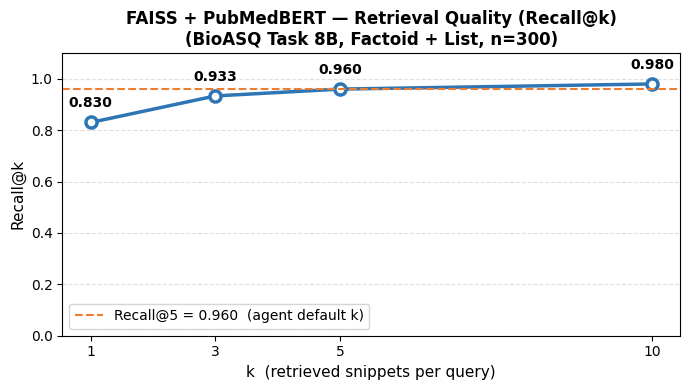

Chart saved -> /content/drive/MyDrive/csci_e222/Final/recall_at_k.png


In [16]:
k_vals      = list(recall_scores.keys())
recall_vals = [recall_scores[k] for k in k_vals]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_vals, recall_vals, marker='o', color='#2E75B6',
        linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2.5)
for k, r in zip(k_vals, recall_vals):
    ax.annotate(f'{r:.3f}', (k, r), textcoords='offset points',
                xytext=(0, 11), ha='center', fontsize=10, fontweight='bold')
ax.axhline(y=recall_scores[5], color='#ED7D31', linestyle='--', linewidth=1.5,
           label=f"Recall@5 = {recall_scores[5]:.3f}  (agent default k)")
ax.set_xlabel('k  (retrieved snippets per query)', fontsize=11)
ax.set_ylabel('Recall@k', fontsize=11)
ax.set_title(
    f'FAISS + PubMedBERT — Retrieval Quality (Recall@k)\n'
    f'(BioASQ Task 8B, Factoid + List, n={n_eval})',
    fontsize=12, fontweight='bold')
ax.set_xticks(k_vals)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(fontsize=10)
plt.tight_layout()
out = os.path.join(BASE_DIR, 'recall_at_k.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved -> {out}')

---
## Cell 16 — Save Question Splits for Notebooks 2–5

In [17]:
np.random.seed(SEED)
shuffled = np.random.permutation(len(train_eval_qs)).tolist()
val_cut  = int(len(shuffled) * 0.1)

val_qs   = [train_eval_qs[i] for i in shuffled[:val_cut]]
train_qs = [train_eval_qs[i] for i in shuffled[val_cut:]]
test_qs  = test_eval_qs

splits = {'train': train_qs, 'val': val_qs, 'test': test_qs}

SPLITS_PATH = os.path.join(INDEX_DIR, 'question_splits.pkl')
with open(SPLITS_PATH, 'wb') as f:
    pickle.dump(splits, f)

print('Question splits saved (Factoid + List only)')
print(f'  Train (few-shot pool) : {len(train_qs):,}')
print(f'  Validation            : {len(val_qs):,}')
print(f'  Test (held-out)       : {len(test_qs):,}')
print(f'\nSaved -> {SPLITS_PATH}')

Question splits saved (Factoid + List only)
  Train (few-shot pool) : 1,427
  Validation            : 158
  Test (held-out)       : 226

Saved -> /content/drive/MyDrive/csci_e222/Final/index/question_splits.pkl


---
## Cell 17 — Notebook 1 Summary

In [18]:
print('=' * 65)
print('NOTEBOOK 1 COMPLETE — OUTPUT SUMMARY')
print('=' * 65)
print(f"""
Dataset
  Training questions         : {len(train_questions):,}
  Test questions (golden)    : {len(golden_questions):,}

Embedding Model
  Name       : {EMBED_MODEL_NAME}
  Dimension  : {EMBED_DIM} (vs 384 for general-purpose MiniLM baseline)
  Domain     : Biomedical (PubMed abstracts + full-text articles)

FAISS Corpus
  Unique snippets indexed    : {len(corpus_snippets):,}
  Index type                 : IndexFlatIP (exact cosine, no approximation)

Retrieval Quality  (Recall@k, n={n_eval})
  Recall@1                   : {recall_scores[1]:.3f}
  Recall@3                   : {recall_scores[3]:.3f}
  Recall@5 (agent default)   : {recall_scores[5]:.3f}
  Recall@10                  : {recall_scores[10]:.3f}

Question Splits (Factoid + List)
  Train (few-shot pool)      : {len(train_qs):,}
  Validation                 : {len(val_qs):,}
  Test (held-out)            : {len(test_qs):,}

Saved Artifacts  ->  {INDEX_DIR}/
  corpus_snippets.pkl      ({os.path.getsize(os.path.join(INDEX_DIR,'corpus_snippets.pkl'))/1e6:.1f} MB)
  corpus_embeddings.npy    ({corpus_embeddings.nbytes/1e6:.1f} MB)
  bioasq_faiss.index       ({os.path.getsize(os.path.join(INDEX_DIR,'bioasq_faiss.index'))/1e6:.1f} MB)
  question_splits.pkl
""")
print('=' * 65)
print('-> Proceed to Notebook 2: ReAct Agent Ablation Study')
print('=' * 65)

NOTEBOOK 1 COMPLETE — OUTPUT SUMMARY

Dataset
  Training questions         : 3,243
  Test questions (golden)    : 500

Embedding Model
  Name       : pritamdeka/S-PubMedBert-MS-MARCO
  Dimension  : 768 (vs 384 for general-purpose MiniLM baseline)
  Domain     : Biomedical (PubMed abstracts + full-text articles)

FAISS Corpus
  Unique snippets indexed    : 38,939
  Index type                 : IndexFlatIP (exact cosine, no approximation)

Retrieval Quality  (Recall@k, n=300)
  Recall@1                   : 0.830
  Recall@3                   : 0.933
  Recall@5 (agent default)   : 0.960
  Recall@10                  : 0.980

Question Splits (Factoid + List)
  Train (few-shot pool)      : 1,427
  Validation                 : 158
  Test (held-out)            : 226

Saved Artifacts  ->  /content/drive/MyDrive/csci_e222/Final/index/
  corpus_snippets.pkl      (11.6 MB)
  corpus_embeddings.npy    (119.6 MB)
  bioasq_faiss.index       (119.6 MB)
  question_splits.pkl

-> Proceed to Notebook 2: Re